# Learn The Quantum Superposition

This notebook learns the **quantum state itself**. The target function is sampled on a fixed grid, encoded as a target probability or signed quasi-probability profile, and a trainable superposition is optimized so that **measurements of the learned state** reproduce that profile.

The key idea is different from notebook 04:

- notebook 04 learns a classical surrogate profile
- notebook 05 learns the **superposition** that is later measured

The displayed function shape always comes from measurement outcomes of the learned state.


In [21]:
import sys
from pathlib import Path

for _p in (Path.cwd(), Path.cwd().parent):
    if (_p / "qfun").is_dir():
        _root = str(_p.resolve())
        if _root not in sys.path:
            sys.path.insert(0, _root)
        break

import numpy as np
import matplotlib.pyplot as plt
import pennylane as qml

from qfun.encode import grid_x
from qfun.plot import plot_comparison, plot_signed_comparison
from qfun.quantum_learning import (
    measure_mode_a_superposition,
    measure_mode_b_superposition,
    measure_standard_superposition,
    target_probability_from_function,
    target_signed_profile_from_function,
    train_mode_a_superposition,
    train_mode_b_superposition,
    train_standard_superposition,
)
from qfun.simulate import estimate_expectation_signed


def plot_loss_and_exact_grid(x, target, learned, losses, *, ylabel, title):
    fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(10, 3.5))
    ax0.plot(losses)
    ax0.set_title("Training loss")
    ax0.set_xlabel("Epoch")
    ax0.set_ylabel("MSE")

    ax1.plot(x, target, "k--", lw=2, label="target")
    ax1.plot(x, learned, lw=2, label="learned (exact probs)")
    ax1.set_xlabel("x")
    ax1.set_ylabel(ylabel)
    ax1.set_title(title)
    ax1.legend(loc="best")
    plt.tight_layout()
    plt.show()


def plot_snapshot_progress(
    losses,
    training_snapshots,
    training_curve_snapshots,
    x_snap,
    y_true,
    *,
    snapshot_interval,
    curve_title,
    ylabel,
):
    if training_snapshots:
        plt.figure(figsize=(6, 3))
        plt.plot(losses, label="MSE")
        if training_curve_snapshots:
            for s, _, _ in training_curve_snapshots:
                if s >= 0:
                    plt.axvline(s, color="gray", alpha=0.4, linewidth=0.8)
        else:
            for s, _ in training_snapshots:
                if s >= 0 and (s % snapshot_interval == 0 or s == len(losses) - 1):
                    plt.axvline(s, color="gray", alpha=0.4, linewidth=0.8)
        plt.title("Training loss (vertical lines = curve snapshots)")
        plt.xlabel("Epoch")
        plt.ylabel("MSE")
        plt.legend()
        plt.show()

        subsample = training_snapshots[:: max(1, len(training_snapshots) // 8)]
        print("Epoch | MSE at snapshot")
        for s, mse in subsample:
            print(f"{s:5d} | {mse:.6g}")
    else:
        print("No snapshots recorded (rerun the training cell).")

    if x_snap is not None and training_curve_snapshots:
        fig, ax = plt.subplots(figsize=(7, 4))
        ax.plot(x_snap, y_true, "k--", linewidth=2, label="target")
        cmap = plt.cm.viridis
        steps_list = [s for s, _, _ in training_curve_snapshots]
        smin, smax = min(steps_list), max(steps_list)
        for s, _mse, y_hat in training_curve_snapshots:
            t = 0.0 if smax == smin else (s - smin) / (smax - smin)
            ax.plot(x_snap, y_hat, color=cmap(t), alpha=0.85, linewidth=1.2)
        sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=smin, vmax=smax))
        sm.set_array([])
        fig.colorbar(sm, ax=ax, label="training step (snapshot)")
        ax.set_title(curve_title)
        ax.set_xlabel("x")
        ax.set_ylabel(ylabel)
        ax.legend(loc="best")
        plt.show()
    else:
        print("No curve snapshots recorded (rerun the training cell).")


def print_top_counts(counts, x, *, signed=False, topn=10):
    print("Top measured bitstrings:")
    for bs, count in sorted(counts.items(), key=lambda kv: kv[1], reverse=True)[:topn]:
        if signed:
            idx = int(bs[:-1], 2)
            sign = "+" if bs[-1] == "0" else "-"
            print(f"  |{bs}>  (x={x[idx]:.3f}, sign={sign}) -> {count}")
        else:
            idx = int(bs, 2)
            print(f"  |{bs}>  (x={x[idx]:.3f}) -> {count}")


## Config

The notebook keeps the grid fixed and learns only the superposition. By default, training uses exact `qml.probs` for stability, while the final displayed profile is always measurement-based.


In [22]:
n_qubits_std = 4
n_qubits_signed = 4

steps = 80
comparison_steps = 50
lr = 0.12
model_seed = 82
log_every = 5
snapshot_interval = 25

training_shots = None
noisy_training_shots = 2_000
eval_shots = 50_000

domain_std = (-2.0, 2.0)
f_std = lambda x: np.exp(-x**2) + 0.15
f_std_label = "exp(-x^2) + 0.15"

domain_a = (0.0, 2.0 * np.pi)
f_mode_a = lambda x: np.sin(x) + 0.35 * np.cos(2.0 * x) + np.exp(-x)
f_mode_a_label = f_mode_a.__name__

domain_b = (0.0, 2.0 * np.pi)
f_mode_b = lambda x: np.cos(x) + np.exp(-x)
f_mode_b_label = f_mode_b.__name__


## 1. Standard nonnegative superposition learning

A real amplitude vector of length `2**n_qubits` is trained, normalized into a valid state, prepared with `qml.MottonenStatePreparation`, and optimized so the measured probability profile matches the nonnegative target function on the grid.


  epoch 5/80  train_mse=0.000420
  epoch 10/80  train_mse=0.000579
  epoch 15/80  train_mse=0.000254
  epoch 20/80  train_mse=0.000177
  epoch 25/80  train_mse=0.000079
  epoch 30/80  train_mse=0.000035
  epoch 35/80  train_mse=0.000024
  epoch 40/80  train_mse=0.000016
  epoch 45/80  train_mse=0.000010
  epoch 50/80  train_mse=0.000005
  epoch 55/80  train_mse=0.000003
  epoch 60/80  train_mse=0.000003
  epoch 65/80  train_mse=0.000001
  epoch 70/80  train_mse=0.000001
  epoch 75/80  train_mse=0.000000
  epoch 80/80  train_mse=0.000000
Target mass                 = 1.000000
Exact learned mass          = 1.000000
Measured mass               = 1.000000
Exact L1 error              = 0.007420
Measured L1 error           = 0.016001
Learned amplitudes:
[-0.1343  0.1467  0.1726 -0.2079 -0.2506 -0.2959 -0.3347 -0.3545  0.3543
  0.3328 -0.2968 -0.2504  0.2096 -0.1698  0.146  -0.1347]
Top measured bitstrings:
  |0111>  (x=-0.133) -> 6266
  |1000>  (x=0.133) -> 6195
  |0110>  (x=-0.400) -> 5703


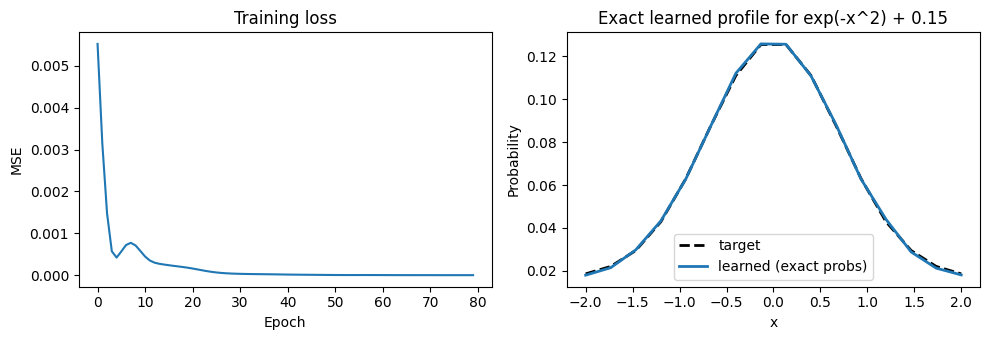

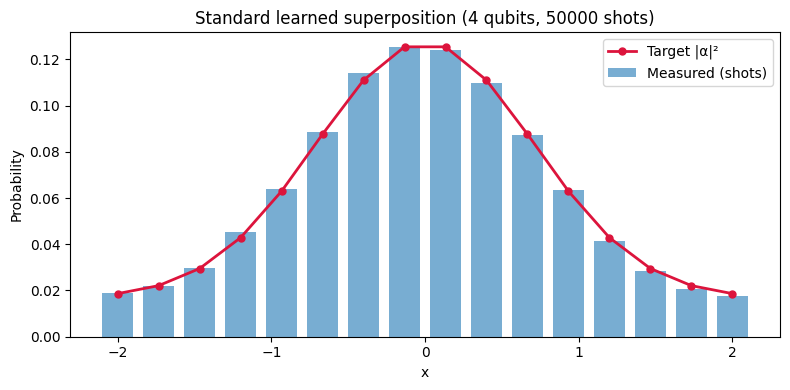

In [23]:
x_std = grid_x(*domain_std, n_qubits_std)
target_prob_std = target_probability_from_function(f_std, x_std)

standard_training_snapshots: list[tuple[int, float]] = []
standard_training_curve_snapshots: list[tuple[int, float, np.ndarray]] = []
x_snap_std = x_std.copy()


def standard_after_step(step: int, loss: float, profile: np.ndarray) -> None:
    standard_training_snapshots.append((step, loss))
    if step == -1 or step % snapshot_interval == 0 or step == steps - 1:
        standard_training_curve_snapshots.append((step, loss, np.asarray(profile, dtype=float)))


std_res = train_standard_superposition(
    target_prob_std,
    n_qubits=n_qubits_std,
    steps=steps,
    learning_rate=lr,
    seed=model_seed,
    training_shots=training_shots,
    log_every=log_every,
    after_step=standard_after_step,
)
std_meas = measure_standard_superposition(std_res.amplitudes, n_qubits_std, shots=eval_shots)

print(f"Target mass                 = {target_prob_std.sum():.6f}")
print(f"Exact learned mass          = {std_res.probs.sum():.6f}")
print(f"Measured mass               = {std_meas.probs.sum():.6f}")
print(f"Exact L1 error              = {np.sum(np.abs(std_res.probs - target_prob_std)):.6f}")
print(f"Measured L1 error           = {np.sum(np.abs(std_meas.probs - target_prob_std)):.6f}")
print("Learned amplitudes:")
print(np.round(std_res.amplitudes, 4))
print_top_counts(std_meas.counts, x_std)

plot_loss_and_exact_grid(
    x_std,
    target_prob_std,
    std_res.probs,
    std_res.losses,
    ylabel="Probability",
    title=f"Exact learned profile for {f_std_label}",
)

plot_comparison(
    x_std,
    target_prob_std,
    std_meas.probs,
    title=f"Standard learned superposition ({n_qubits_std} qubits, {eval_shots} shots)",
)


### Standard training process (snapshots)

This mirrors notebook 04: every 5 epochs, the notebook records the current learned curve so you can see how the superposition moves toward the target.


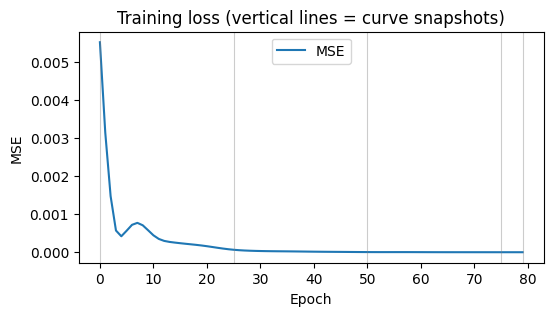

Epoch | MSE at snapshot
   -1 | 0.00552344
    9 | 0.000578545
   19 | 0.000177423
   29 | 3.52887e-05
   39 | 1.63622e-05
   49 | 4.81196e-06
   59 | 2.81686e-06
   69 | 7.09738e-07
   79 | 3.5832e-07


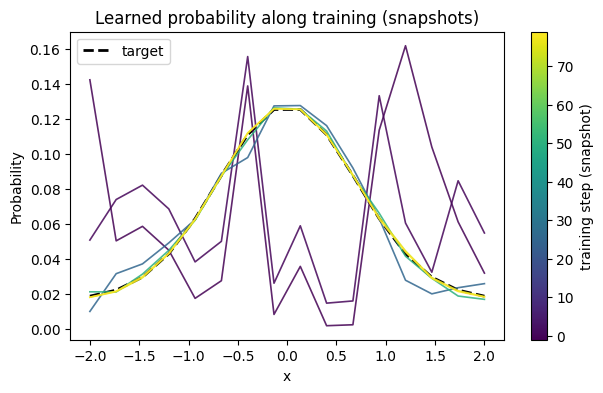

In [24]:
plot_snapshot_progress(
    std_res.losses,
    standard_training_snapshots,
    standard_training_curve_snapshots,
    x_snap_std,
    target_prob_std,
    snapshot_interval=snapshot_interval,
    curve_title="Learned probability along training (snapshots)",
    ylabel="Probability",
)


### Standard circuit

This is the actual state-preparation circuit used to show the learned function through measurements.


## 2. Mode A signed learning with an ancilla sign qubit

Here the trainable state lives on `n_qubits + 1` wires. The last wire is treated as an ancilla sign bit, so measurement outcomes with ancilla `0` contribute to the positive channel and ancilla `1` contribute to the negative channel.


  epoch 5/80  train_mse=0.000495
  epoch 10/80  train_mse=0.000085
  epoch 15/80  train_mse=0.000107
  epoch 20/80  train_mse=0.000054
  epoch 25/80  train_mse=0.000055
  epoch 30/80  train_mse=0.000035
  epoch 35/80  train_mse=0.000021
  epoch 40/80  train_mse=0.000016
  epoch 45/80  train_mse=0.000010
  epoch 50/80  train_mse=0.000008
  epoch 55/80  train_mse=0.000006
  epoch 60/80  train_mse=0.000004
  epoch 65/80  train_mse=0.000003
  epoch 70/80  train_mse=0.000003
  epoch 75/80  train_mse=0.000002
  epoch 80/80  train_mse=0.000002
Target signed mass          = 1.000000
Exact p_pos + p_neg         = 1.000000
Measured p_pos + p_neg      = 1.000000
Exact signed L1 error       = 0.019478
Measured signed L1 error    = 0.021391
First extended amplitudes:
[ 0.3183  0.0008  0.3116 -0.0043 -0.2915 -0.006  -0.2659 -0.0052  0.2492
  0.001  -0.2508  0.0513] ...
Top measured bitstrings:
  |00000>  (x=0.000, sign=+) -> 5054
  |10111>  (x=4.608, sign=-) -> 4969
  |00010>  (x=0.419, sign=+) -> 4

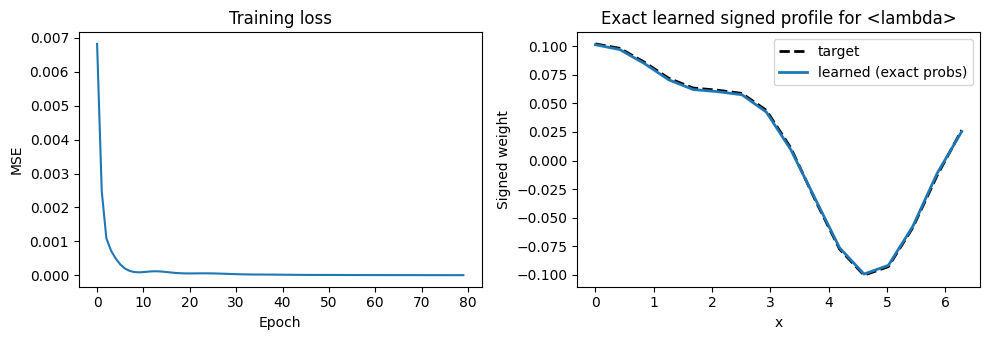

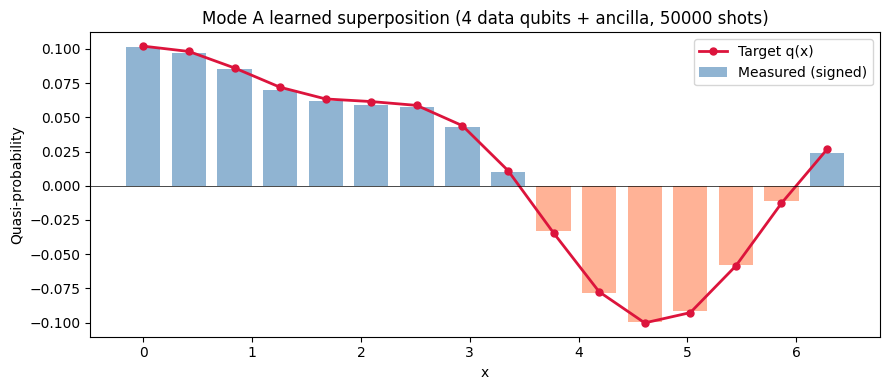

In [25]:
x_a = grid_x(*domain_a, n_qubits_signed)
target_q_a = target_signed_profile_from_function(f_mode_a, x_a)

mode_a_training_snapshots: list[tuple[int, float]] = []
mode_a_training_curve_snapshots: list[tuple[int, float, np.ndarray]] = []
x_snap_a = x_a.copy()


def mode_a_after_step(step: int, loss: float, profile: np.ndarray) -> None:
    mode_a_training_snapshots.append((step, loss))
    if step == -1 or step % snapshot_interval == 0 or step == steps - 1:
        mode_a_training_curve_snapshots.append((step, loss, np.asarray(profile, dtype=float)))


mode_a_res = train_mode_a_superposition(
    target_q_a,
    n_qubits=n_qubits_signed,
    steps=steps,
    learning_rate=lr,
    seed=model_seed,
    training_shots=training_shots,
    log_every=log_every,
    after_step=mode_a_after_step,
)
mode_a_meas = measure_mode_a_superposition(mode_a_res.amplitudes, n_qubits_signed, shots=eval_shots)

print(f"Target signed mass          = {np.sum(np.abs(target_q_a)):.6f}")
print(f"Exact p_pos + p_neg         = {mode_a_res.p_pos.sum() + mode_a_res.p_neg.sum():.6f}")
print(f"Measured p_pos + p_neg      = {mode_a_meas.p_pos.sum() + mode_a_meas.p_neg.sum():.6f}")
print(f"Exact signed L1 error       = {np.sum(np.abs(mode_a_res.q - target_q_a)):.6f}")
print(f"Measured signed L1 error    = {np.sum(np.abs(mode_a_meas.q - target_q_a)):.6f}")
print("First extended amplitudes:")
print(np.round(mode_a_res.amplitudes[:12], 4), "...")
print_top_counts(mode_a_meas.counts, x_a, signed=True)

plot_loss_and_exact_grid(
    x_a,
    target_q_a,
    mode_a_res.q,
    mode_a_res.losses,
    ylabel="Signed weight",
    title=f"Exact learned signed profile for {f_mode_a_label}",
)

plot_signed_comparison(
    x_a,
    target_q_a,
    mode_a_meas.q,
    title=f"Mode A learned superposition ({n_qubits_signed} data qubits + ancilla, {eval_shots} shots)",
)


### Mode A training process (snapshots)

The recorded curves below are the exact signed reconstructions of the learned ancilla-based state every 5 epochs.


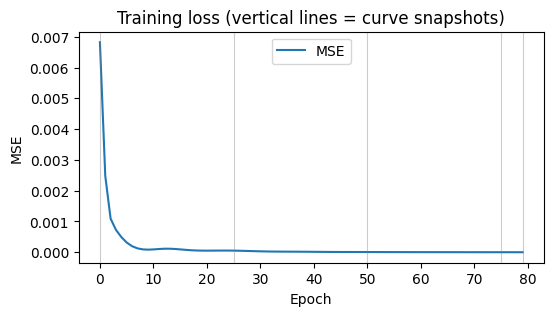

Epoch | MSE at snapshot
   -1 | 0.00682492
    9 | 8.52129e-05
   19 | 5.37918e-05
   29 | 3.53754e-05
   39 | 1.63985e-05
   49 | 7.8651e-06
   59 | 4.31445e-06
   69 | 2.55915e-06
   79 | 1.60509e-06


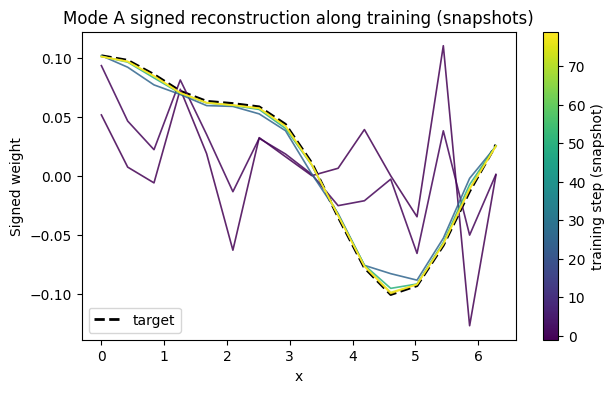

In [26]:
plot_snapshot_progress(
    mode_a_res.losses,
    mode_a_training_snapshots,
    mode_a_training_curve_snapshots,
    x_snap_a,
    target_q_a,
    snapshot_interval=snapshot_interval,
    curve_title="Mode A signed reconstruction along training (snapshots)",
    ylabel="Signed weight",
)


### Mode A circuit

The same learned extended state is prepared and measured; only the interpretation of the last bit changes.


## 3. Mode B signed learning with two quantum channels

Mode B learns two nonnegative quantum states, `p_plus` and `p_minus`, together with trainable channel weights `z_plus` and `z_minus`. The signed profile is reconstructed as

`q_hat(x) = z_plus * p_plus(x) - z_minus * p_minus(x)`.


  epoch 5/80  train_mse=0.000481
  epoch 10/80  train_mse=0.000304
  epoch 15/80  train_mse=0.000129
  epoch 20/80  train_mse=0.000116
  epoch 25/80  train_mse=0.000071
  epoch 30/80  train_mse=0.000034
  epoch 35/80  train_mse=0.000021
  epoch 40/80  train_mse=0.000015
  epoch 45/80  train_mse=0.000009
  epoch 50/80  train_mse=0.000006
  epoch 55/80  train_mse=0.000005
  epoch 60/80  train_mse=0.000003
  epoch 65/80  train_mse=0.000003
  epoch 70/80  train_mse=0.000002
  epoch 75/80  train_mse=0.000002
  epoch 80/80  train_mse=0.000001
Learned z_plus              = 0.652990
Learned z_minus             = 0.347010
z_plus + z_minus            = 1.000000
Exact signed L1 error       = 0.017289
Measured signed L1 error    = 0.017416


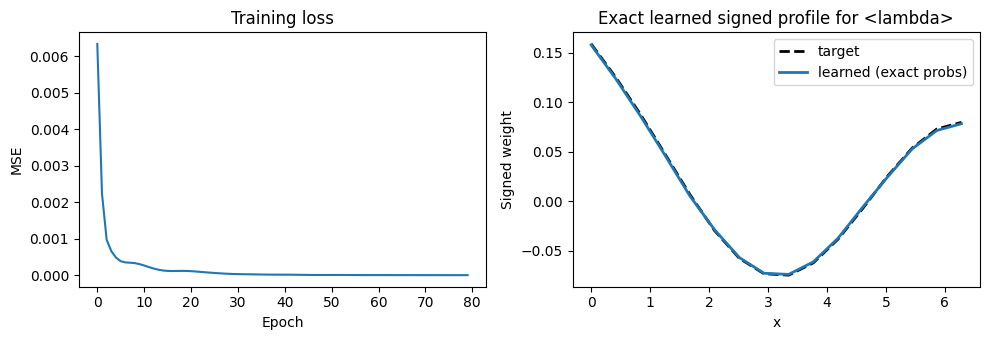

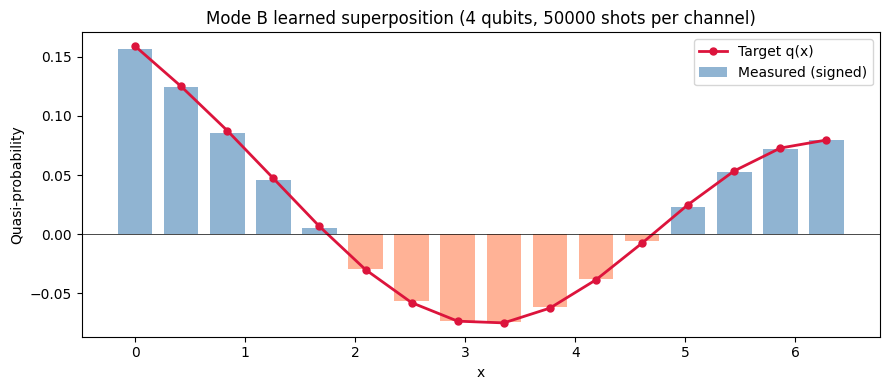

In [27]:
x_b = grid_x(*domain_b, n_qubits_signed)
target_q_b = target_signed_profile_from_function(f_mode_b, x_b)

mode_b_training_snapshots: list[tuple[int, float]] = []
mode_b_training_curve_snapshots: list[tuple[int, float, np.ndarray]] = []
x_snap_b = x_b.copy()


def mode_b_after_step(step: int, loss: float, profile: np.ndarray) -> None:
    mode_b_training_snapshots.append((step, loss))
    if step == -1 or step % snapshot_interval == 0 or step == steps - 1:
        mode_b_training_curve_snapshots.append((step, loss, np.asarray(profile, dtype=float)))


mode_b_res = train_mode_b_superposition(
    target_q_b,
    n_qubits=n_qubits_signed,
    steps=steps,
    learning_rate=lr,
    seed=model_seed,
    training_shots=training_shots,
    log_every=log_every,
    after_step=mode_b_after_step,
)
mode_b_meas = measure_mode_b_superposition(
    mode_b_res.p_plus_amplitudes,
    mode_b_res.p_minus_amplitudes,
    mode_b_res.z_plus,
    mode_b_res.z_minus,
    n_qubits_signed,
    shots=eval_shots,
)

print(f"Learned z_plus              = {mode_b_res.z_plus:.6f}")
print(f"Learned z_minus             = {mode_b_res.z_minus:.6f}")
print(f"z_plus + z_minus            = {mode_b_res.z_plus + mode_b_res.z_minus:.6f}")
print(f"Exact signed L1 error       = {np.sum(np.abs(mode_b_res.q - target_q_b)):.6f}")
print(f"Measured signed L1 error    = {np.sum(np.abs(mode_b_meas.q_hat - target_q_b)):.6f}")

plot_loss_and_exact_grid(
    x_b,
    target_q_b,
    mode_b_res.q,
    mode_b_res.losses,
    ylabel="Signed weight",
    title=f"Exact learned signed profile for {f_mode_b_label}",
)

plot_signed_comparison(
    x_b,
    target_q_b,
    mode_b_meas.q_hat,
    title=f"Mode B learned superposition ({n_qubits_signed} qubits, {eval_shots} shots per channel)",
)


### Mode B training process (snapshots)

These curves show the exact two-channel signed reconstruction every 5 epochs, before the final shot-based evaluation.


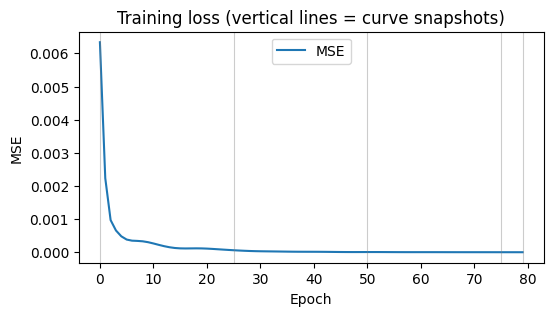

Epoch | MSE at snapshot
   -1 | 0.00633574
    9 | 0.00030385
   19 | 0.000116399
   29 | 3.36659e-05
   39 | 1.49966e-05
   49 | 6.41041e-06
   59 | 3.31737e-06
   69 | 2.0886e-06
   79 | 1.32648e-06


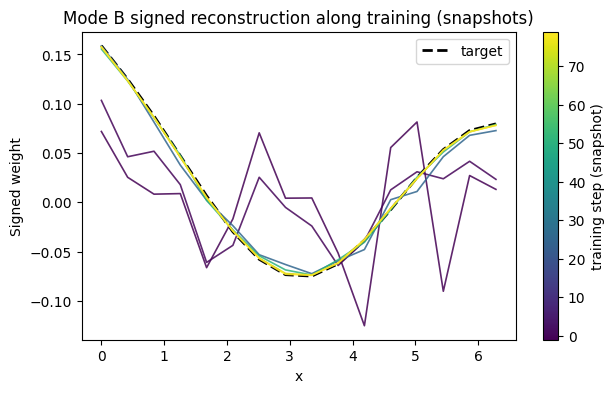

In [28]:
plot_snapshot_progress(
    mode_b_res.losses,
    mode_b_training_snapshots,
    mode_b_training_curve_snapshots,
    x_snap_b,
    target_q_b,
    snapshot_interval=snapshot_interval,
    curve_title="Mode B signed reconstruction along training (snapshots)",
    ylabel="Signed weight",
)


### Mode B expectation estimation

Just like notebook 01, the two-channel reconstruction can be used to estimate expectations under the learned signed profile.


In [29]:
g = x_b
e_target = np.dot(g, target_q_b)
e_meas = estimate_expectation_signed(
    g,
    mode_b_meas.p_plus_hat,
    mode_b_meas.p_minus_hat,
    mode_b_meas.z_plus,
    mode_b_meas.z_minus,
)

g2 = x_b**2
e2_target = np.dot(g2, target_q_b)
e2_meas = estimate_expectation_signed(
    g2,
    mode_b_meas.p_plus_hat,
    mode_b_meas.p_minus_hat,
    mode_b_meas.z_plus,
    mode_b_meas.z_minus,
)

print(f"E_q[x]    target  = {e_target:.6f}")
print(f"E_q[x]    measured= {e_meas:.6f}")
print(f"E_q[x^2]  target  = {e2_target:.6f}")
print(f"E_q[x^2]  measured= {e2_meas:.6f}")


E_q[x]    target  = 0.434093
E_q[x]    measured= 0.429898
E_q[x^2]  target  = 4.346989
E_q[x^2]  measured= 4.309675


### Mode B circuits

Both channels are ordinary state-preparation circuits. The sign only appears when the two measured channels are recombined with the learned weights.


## 4. Exact training vs finite-shot training

Training with exact `qml.probs` is usually smoother, but the measured output is still the main object we care about. This block reruns the standard example with finite-shot probabilities during optimization to show the noisier training curve.


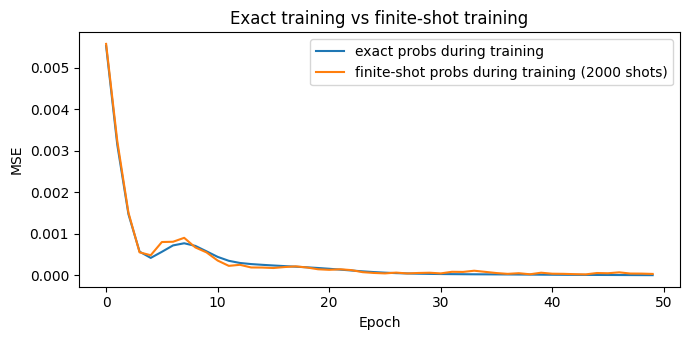

Both models below are still shown through final measurement histograms.
Measured L1 error after exact training: 0.025732
Measured L1 error after shot training:  0.047000


In [30]:
std_exact_train = train_standard_superposition(
    target_prob_std,
    n_qubits=n_qubits_std,
    steps=comparison_steps,
    learning_rate=lr,
    seed=model_seed,
    training_shots=None,
)
std_shot_train = train_standard_superposition(
    target_prob_std,
    n_qubits=n_qubits_std,
    steps=comparison_steps,
    learning_rate=lr,
    seed=model_seed,
    training_shots=noisy_training_shots,
)

std_exact_meas = measure_standard_superposition(std_exact_train.amplitudes, n_qubits_std, shots=eval_shots)
std_shot_meas = measure_standard_superposition(std_shot_train.amplitudes, n_qubits_std, shots=eval_shots)

plt.figure(figsize=(7, 3.5))
plt.plot(std_exact_train.losses, label="exact probs during training")
plt.plot(std_shot_train.losses, label=f"finite-shot probs during training ({noisy_training_shots} shots)")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Exact training vs finite-shot training")
plt.legend(loc="best")
plt.tight_layout()
plt.show()

print("Both models below are still shown through final measurement histograms.")
print(f"Measured L1 error after exact training: {np.sum(np.abs(std_exact_meas.probs - target_prob_std)):.6f}")
print(f"Measured L1 error after shot training:  {np.sum(np.abs(std_shot_meas.probs - target_prob_std)):.6f}")
